In [ ]:
#!pip install langchain langchain-community langchain-text-splitters chromadb pypdf sentence-transformers

In [1]:
import os
import shutil
import matplotlib.pyplot as plt
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import OllamaEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_community.llms import Ollama
from langchain_core.prompts import PromptTemplate

# 1. CLEANUP: Delete old database to prevent duplicate results
if os.path.exists("./chroma_notebook_db"):
    shutil.rmtree("./chroma_notebook_db")
if os.path.exists("./chroma_transformer_db_mini"):
    shutil.rmtree("./chroma_transformer_db_mini")

# 2. LOAD DATA
PDF_PATH = "Attention Is All You Need.pdf"
loader = PyPDFLoader(PDF_PATH)
docs = loader.load()

# 3. CHUNKING STRATEGY
# Larger chunks for Nomic (Stage 1)
nomic_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)
nomic_chunks = nomic_splitter.split_documents(docs)

# Smaller chunks for MiniLM (Safety fix for 256 token limit)
mini_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=50)
mini_chunks = mini_splitter.split_documents(docs)

print(f"✅ Loaded {len(docs)} pages.")
print(f"✅ Created {len(nomic_chunks)} Nomic chunks and {len(mini_chunks)} MiniLM chunks.")

c:\Users\Yash\OneDrive\Desktop\Coding\RAG test\venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
c:\Users\Yash\OneDrive\Desktop\Coding\RAG test\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Loaded 15 pages.
✅ Created 49 Nomic chunks and 119 MiniLM chunks.


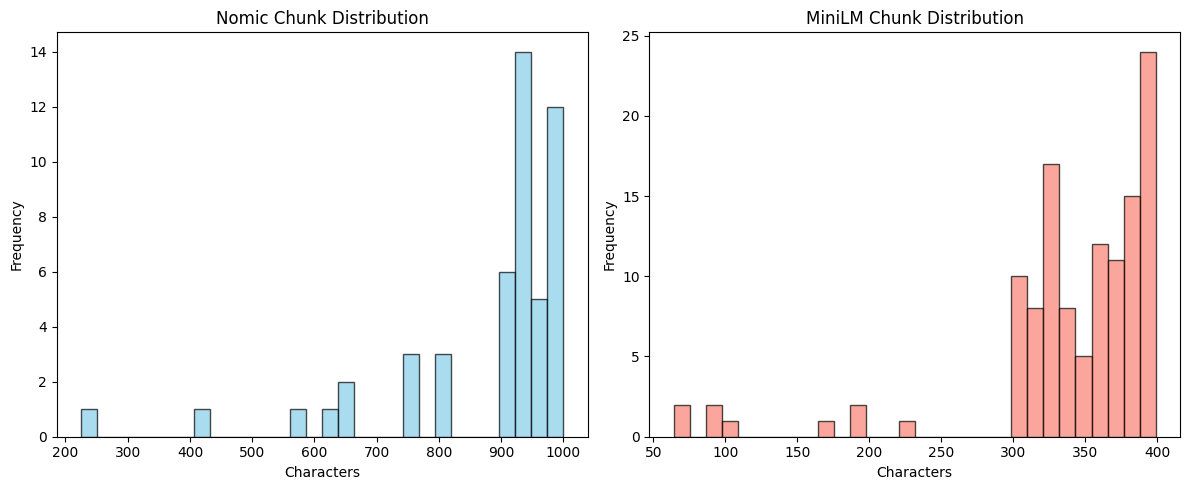

In [2]:
def plot_dist(chunks, title, color):
    lengths = [len(c.page_content) for c in chunks]
    plt.hist(lengths, bins=30, color=color, edgecolor='black', alpha=0.7)
    plt.title(title)
    plt.xlabel("Characters")
    plt.ylabel("Frequency")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_dist(nomic_chunks, "Nomic Chunk Distribution", "skyblue")
plt.subplot(1, 2, 2)
plot_dist(mini_chunks, "MiniLM Chunk Distribution", "salmon")
plt.tight_layout()
plt.show()

In [3]:
print("Building Nomic Database (768 Dimensions)...")
nomic_db = Chroma.from_documents(
    documents=nomic_chunks, 
    embedding=OllamaEmbeddings(model="nomic-embed-text"),
    collection_name="nomic_vdb",
    persist_directory="./chroma_notebook_db"
)

print("Building MiniLM Database (384 Dimensions)...")
mini_db = Chroma.from_documents(
    documents=mini_chunks, 
    embedding=OllamaEmbeddings(model="all-minilm"),
    collection_name="mini_vdb",
    persist_directory="./chroma_transformer_db_mini"
)
print("✅ Databases Ready.")

Building Nomic Database (768 Dimensions)...


C:\Users\Yash\AppData\Local\Temp\ipykernel_33196\4080414434.py:4: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaEmbeddings``.
  embedding=OllamaEmbeddings(model="nomic-embed-text"),


Building MiniLM Database (384 Dimensions)...
✅ Databases Ready.


In [4]:
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

# Initialize LLM and Re-ranker
llm = Ollama(model="llama3", temperature=0.0)
cross_encoder_model = HuggingFaceCrossEncoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2")
reranker = CrossEncoderReranker(model=cross_encoder_model, top_n=3)

def run_showdown(query):
    print(f"\n🚀 QUERY: {query}\n" + "="*50)
    
    # Retrieval
    nomic_res = nomic_db.similarity_search(query, k=2)
    mini_res = mini_db.similarity_search(query, k=2)
    
    print("\n--- Top 2: Nomic (768d) ---")
    for i, d in enumerate(nomic_res): print(f"{i+1}. {d.page_content[:150]}...")
        
    print("\n--- Top 2: All-MiniLM (384d) ---")
    for i, d in enumerate(mini_res): print(f"{i+1}. {d.page_content[:150]}...")

    # Final Generation using Re-ranking (Production Setup)
    print("\n🧠 Final Llama 3 Answer (using Re-ranked Nomic Context):")
    advanced_retriever = ContextualCompressionRetriever(
        base_compressor=reranker, 
        base_retriever=nomic_db.as_retriever(search_kwargs={"k": 10})
    )
    final_docs = advanced_retriever.invoke(query)
    context = "\n\n".join([d.page_content for d in final_docs])
    
    prompt = f"Use this context to answer: {context}\n\nQuestion: {query}\n\nIf not in context, say DECLINE_TO_ANSWER."
    print(llm.invoke(prompt))

# RUN THE TEST
run_showdown("What are the advantages of self-attention over recurrent layers?")

C:\Users\Yash\AppData\Local\Temp\ipykernel_33196\2194078857.py:6: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm = Ollama(model="llama3", temperature=0.0)
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 15202.00it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🚀 QUERY: What are the advantages of self-attention over recurrent layers?

--- Top 2: Nomic (768d) ---
1. versions produced nearly identical results (see Table 3 row (E)). We chose the sinusoidal version
because it may allow the model to extrapolate to seq...
2. between any two positions in the network. Convolutional layers are generally more expensive than
recurrent layers, by a factor of k. Separable convolu...

--- Top 2: All-MiniLM (384d) ---
1. different layer types.
As noted in Table 1, a self-attention layer connects all positions with a constant number of sequentially
executed operations, ...
2. because it may allow the model to extrapolate to sequence lengths longer than the ones encountered
during training.
4 Why Self-Attention
In this secti...

🧠 Final Llama 3 Answer (using Re-ranked Nomic Context):
According to the text, the advantages of self-attention over recurrent layers are:

1. Lower computational complexity per layer (by a factor of k)
2. More computation that can b